# Лабораторная работа №5, вариант 8

### Цель работы: научиться производить кластерный анализ данных с использованием метода К-средних. 

#### Вариант 8 – Кредитные карты клиентов 

Датасет –  Credit Card Customer Data.csv 

Набор данных содержит информацию о кредитных картах клиентов. Его можно 
использовать для выявления лояльных клиентов, сегментации клиентов, целевого 
маркетинга и других подобных случаев использования в маркетинговой отрасли.

Атрибуты: 


• Sl_No – серийный идентификационный номер клиента, служит для индекса
ции значений 


• Customer Key – ключ клиента 


• Avg_Credit_Limit – средний лимит по кредитной карте для клиента 


• Total_Credit_Cards – общее количество кредитных карт, принадлежащих клиенту 


• Total_visits_bank – общее количество посещений банка клиентом 


• Total_visits_online – общее количество посещений онлайн клиентами банка 


• Total_calls_made – общее количество звонков, сделанных клиентом в банк

**1. Импортируйте необходимые библиотеки и загружаем данные**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Credit Card Customer Data.csv')
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


**2. Получим информацию о датасете**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


**3. Проверяем наличие пропущенных значений и выбросов**

In [4]:
print(df.isnull().sum())

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64


Пропущенные значения и категориальные признаки отсутствуют, следовательно переходим сразу к нормализации.

**4. Применяем операцию нормализации для численной устойчивости**

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


**5. Приведем данные к единому масштабу**

In [6]:
X = scaler.fit_transform(df)
X[:5]

array([[-1.72942847,  1.24691971,  1.74018685, -1.24922476, -0.86045063,
        -0.54748969, -1.25153737],
       [-1.72417983, -0.65320273,  0.41029254, -0.78758515, -1.47373077,
         2.5205186 ,  1.89185881],
       [-1.71893118, -1.47609839,  0.41029254,  1.05897329, -0.86045063,
         0.13428993,  0.1455276 ],
       [-1.71368254, -0.57190112, -0.12166518,  0.13569407, -0.86045063,
        -0.54748969,  0.1455276 ],
       [-1.70843389, -0.30085671,  1.74018685,  0.59733368, -1.47373077,
         3.20229822, -0.20373864]])

**6. Определяем оптимальное количество кластеров методом локтя**

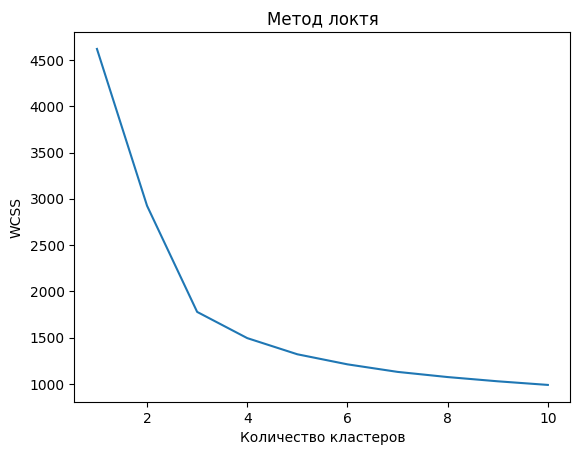

In [7]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

На графике четко виден "локоть" в районе 3-4 кластеров. Определим, что выделено 3 кластера, так как в точке 3 наблюдается наиболее выраженное изменение наклона

**7. Обучаем модель кластеризации**

In [8]:
# заново обучим модель с тремя кластерами
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
# обучаем модель на стандартизированных данных
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


**8. Предсказываем кластеры и визиализируем результаты**

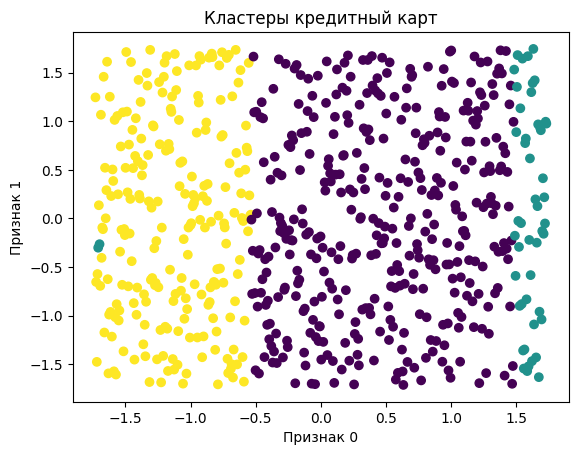

In [9]:
labels = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Кластеры кредитный карт')
plt.xlabel('Признак 0')
plt.ylabel('Признак 1')
plt.show()

Кластеризация успешно выявила 3 четко различимые группы, минимальное перекрытие между кластерами, что подтверждает правильность выбора количества кластеров и эффективность применения метода K-means для данного датасета.

**9. Интерпретируем результаты**

In [10]:
X[:5]

array([[-1.72942847,  1.24691971,  1.74018685, -1.24922476, -0.86045063,
        -0.54748969, -1.25153737],
       [-1.72417983, -0.65320273,  0.41029254, -0.78758515, -1.47373077,
         2.5205186 ,  1.89185881],
       [-1.71893118, -1.47609839,  0.41029254,  1.05897329, -0.86045063,
         0.13428993,  0.1455276 ],
       [-1.71368254, -0.57190112, -0.12166518,  0.13569407, -0.86045063,
        -0.54748969,  0.1455276 ],
       [-1.70843389, -0.30085671,  1.74018685,  0.59733368, -1.47373077,
         3.20229822, -0.20373864]])

In [11]:
labels

array([2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [12]:
df['label'] = labels
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,label
0,1,87073,100000,2,1,1,0,2
1,2,38414,50000,3,0,10,9,2
2,3,17341,50000,7,1,3,4,2
3,4,40496,30000,5,1,1,4,2
4,5,47437,100000,6,0,12,3,1


In [13]:
df.groupby('label').mean()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
label,,,,,,,
0,420.500000,54977.705729,33507.812500,5.518229,3.505208,0.979167,2.000000
1,611.280000,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000
2,115.460177,55072.902655,12831.858407,2.433628,0.929204,3.535398,6.827434


**Кластер 0**
- Avg_Credit_Limit: 33,508 - СРЕДНИЙ лимит (больше чем у кластера 2, но меньше чем у кластера 1)
- Total_Credit_Cards: 5.5 карт - УМЕРЕННОЕ количество
- Total_visits_bank: 3.5 посещений - ВЫСОКАЯ оффлайн-активность (максимум среди всех кластеров)
- Total_visits_online: 1.0 посещений - НИЗКАЯ онлайн-активность (минимум среди всех)
- Total_calls_made: 2.0 звонков - УМЕРЕННАЯ телефонная активность

Эта группа сочетает средние финансовые показатели с предпочтением традиционного банковского обслуживания через отделения.

---

**Кластер 1**
- Avg_Credit_Limit: 141,040 - МАКСИМАЛЬНЫЙ лимит (в 4 раза выше среднего, в 11 раз выше базового)
- Total_Credit_Cards: 8.7 карт - ВЫСОКОЕ количество карт
- Total_visits_bank: 0.6 посещений - МИНИМАЛЬНЫЕ оффлайн-визиты
- Total_visits_online: 10.9 посещений - ОЧЕНЬ ВЫСОКАЯ онлайн-активность
- Total_calls_made: 1.1 звонков - НИЗКАЯ телефонная активность

Эта группа сочетает максимальные финансовые показатели с явным предпочтением использования онлайн платформы

---

**Кластер 2**

**Атрибуты:**
- Avg_Credit_Limit: 12,832 - МИНИМАЛЬНЫЙ лимит (в 2.5 раза ниже среднего, в 11 раз ниже премиального)
- Total_Credit_Cards: 2.4 карты - МИНИМАЛЬНОЕ количество карт
- Total_visits_bank: 0.9 посещений - НИЗКАЯ оффлайн-активность
- Total_visits_online: 3.5 посещений - УМЕРЕННАЯ онлайн-активность
- Total_calls_made: 6.8 звонков - МАКСИМАЛЬНАЯ телефонная активность

Эта группа сочетает минимальные финансовые показатели с максимальной зависимостью от телефонного обслуживания

**Визуализируем кластеры по Avg_Credit_Limit и Total_Credit_Cards (кредитный лимит и количество карт)**

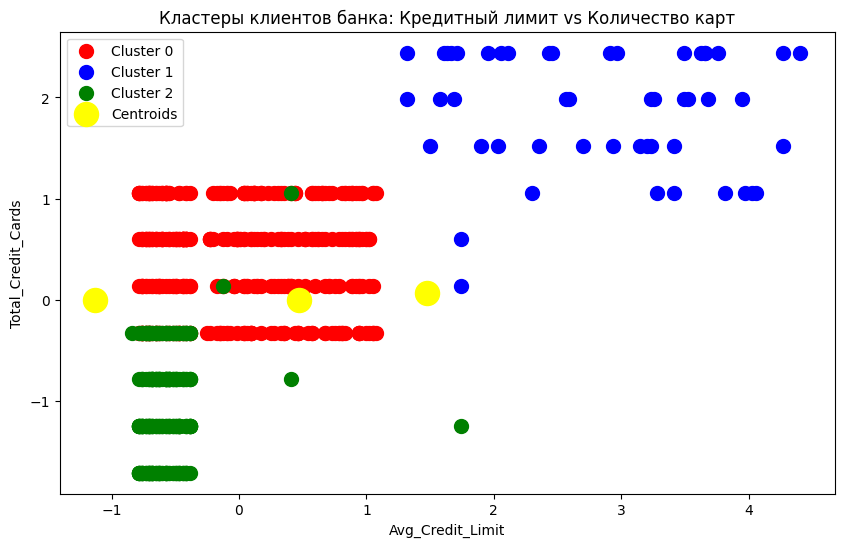

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(X[labels == 0, 2], X[labels == 0, 3], s = 100, c = 'red', label = 'Cluster 0')
plt.scatter(X[labels == 1, 2], X[labels == 1, 3], s = 100, c = 'blue', label = 'Cluster 1')
plt.scatter(X[labels == 2, 2], X[labels == 2, 3], s = 100, c = 'green', label = 'Cluster 2')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    s = 300, c = 'yellow', label = 'Centroids')
plt.title('Кластеры клиентов банка: Кредитный лимит vs Количество карт')
plt.xlabel('Avg_Credit_Limit')
plt.ylabel('Total_Credit_Cards')
plt.legend()
plt.show()

Наиболее выделяется кластер 1, демонстрируя сочетание высокого кредитного лимита с большим количеством карт. Кластер 2 зеленого цвета занимает левую часть графика с низкими значениями по обеим осям.


**Теперь визуализируем кластеры по Total_visits_bank и Total_visits_online (оффлайн и онлайн посещения банков)**

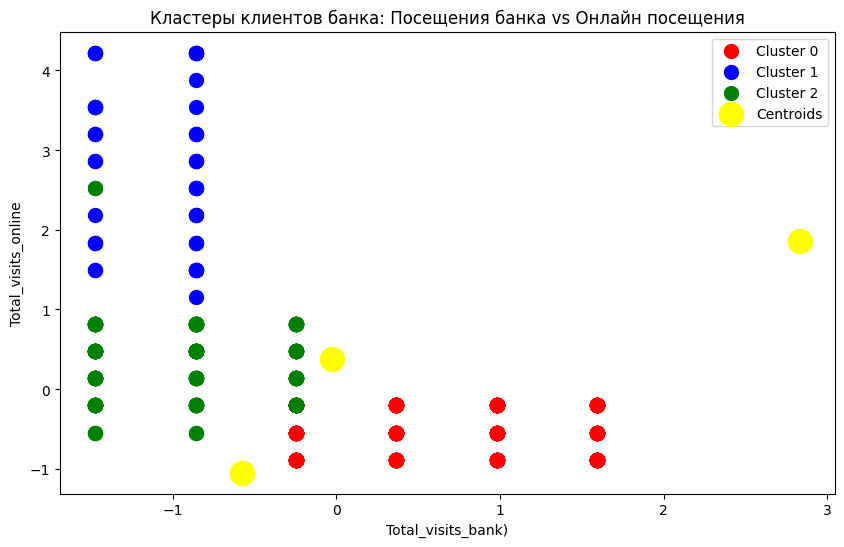

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(X[labels == 0, 4], X[labels == 0, 5], s = 100, c = 'red', label = 'Cluster 0')
plt.scatter(X[labels == 1, 4], X[labels == 1, 5], s = 100, c = 'blue', label = 'Cluster 1')
plt.scatter(X[labels == 2, 4], X[labels == 2, 5], s = 100, c = 'green', label = 'Cluster 2')
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
    s = 300, c = 'yellow', label = 'Centroids')
plt.title('Кластеры клиентов банка: Посещения банка vs Онлайн посещения')
plt.xlabel('Total_visits_bank)')
plt.ylabel('Total_visits_online')
plt.legend()
plt.show()

Кластеры 1 и 2 расположены в левой часты графика, что подтверждает малое количество оффлайн посещений банка, в отличие от кластера 0. И кластер 1 явно выделяется по оси y - высокая активность онлайн посещений. Наблюдается, что при онлайн посещение банка почти не происходит оффлайн посещений, и наоборот.

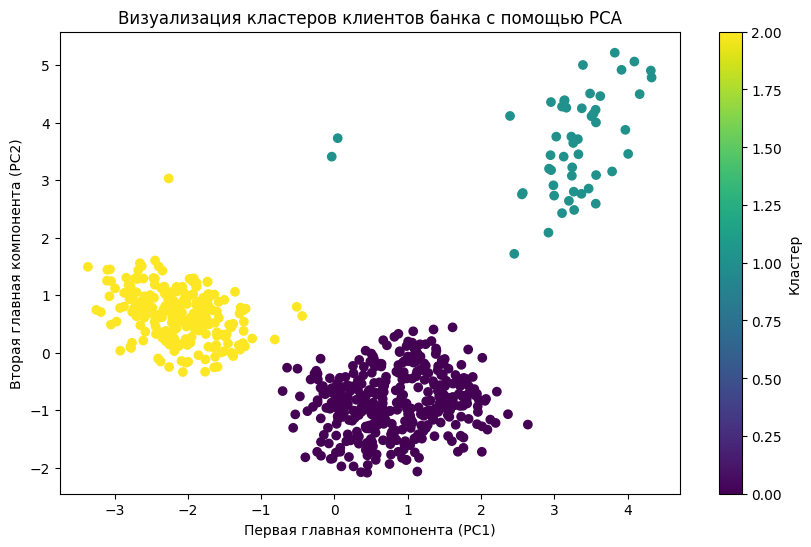

In [17]:
from sklearn.decomposition import PCA

# Уменьшаем размерность до 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.xlabel('Первая главная компонента (PC1)')
plt.ylabel('Вторая главная компонента (PC2)')
plt.title('Визуализация кластеров клиентов банка с помощью PCA')
plt.colorbar(label='Кластер')
plt.show()

Три кластера визуально хорошо различимы, что подтверждает эффективность проведенной кластеризации.


Кластер 0 изображен фиолетовыми точками, занимает центральную нижнюю часть. Кластер 1 изображен голубыми точками, занимает правую верхнюю часть графика. И кластер 2 изображен желтыми точками, состредоточен в левой части по оси x и центрально по оси y.

Кластер 1 наиболее удален от остальных кластеров, что свидетельствует о его выраженной уникальности и существенных отличиях от других групп клиентов. Кластеры 0 и 2 ближе расположены друг к другу. По оси x кластер 0 занимает промежуточное положение между кластерами 1 и 2, это говорит о том, что данный сегмент клиентов обладает смешанными характеристиками, частично схожими с обоими другими кластерами. 